In [56]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz 
from sklearn.model_selection import train_test_split

from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from components.models import ANFISAdvanced, init_mf_params

In [57]:
# ---------------------------
# 1) Preparing the data
# ---------------------------

def make_spirals(n_samples=2000, noise=0.2):
    n = np.sqrt(np.random.rand(n_samples,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_samples,1)*noise
    d1y =  np.sin(n)*n + np.random.rand(n_samples,1)*noise
    X = np.vstack((np.hstack((d1x,d1y)), 
                   np.hstack((-d1x,-d1y))))
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
    return X.astype(np.float32), y.astype(np.int64)

X, y = make_spirals()

# seperate train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [58]:
# ---------------------------
# 5) Training (Classification)
# ---------------------------

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert labels to float for BCE
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1).to(device)

X_train_tensor = torch.from_numpy(X_train).to(device)
X_test_tensor  = torch.from_numpy(X_test).to(device)

# ---------------------------
# Initialization via FCM
# ---------------------------
K = 6
init_method = "fcm"  # choose: "fcm", "random_uniform"
centers_init, spreads_init = init_mf_params(X_train, K, method=init_method, scale=1.0)

# ---------------------------
# Model setup
# ---------------------------
s_mode_choice = "alpha_beta"   # or "C"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# IMPORTANT: logits → use BCEWithLogitsLoss (sigmoid inside)
loss_fn = nn.BCEWithLogitsLoss()

# Keep initial MF parameters for comparison
init_centers = model.mf_layer.c.detach().cpu().clone()
init_spreads = model.mf_layer.s.detach().cpu().clone()

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward
    logits_train = model(X_train_tensor)

    # Loss
    loss = loss_fn(logits_train, y_train_tensor)

    # Backprop
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # Track best
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Progress
    if epoch % 100 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_log = model(X_train_tensor)
            test_log  = model(X_test_tensor)

            train_prob = torch.sigmoid(train_log)
            test_prob  = torch.sigmoid(test_log)

            train_pred = (train_prob >= 0.5).float()
            test_pred = (test_prob >= 0.5).float()

            train_total = y_train_tensor.numel()
            test_total = y_test_tensor.numel()
            train_correct = int((train_pred == y_train_tensor).sum().item())
            test_correct = int((test_pred == y_test_tensor).sum().item())
            train_acc = train_correct / train_total
            test_acc = test_correct / test_total
            train_err = 1.0 - train_acc
            test_err = 1.0 - test_acc

        print(
            f"Epoch {epoch}/{n_epochs}  Loss: {loss.item():.4f}  "
            f"Train Acc: {train_acc:.3f} (Err {train_err:.3f})  "
            f"Test Acc: {test_acc:.3f} (Err {test_err:.3f})"
        )

# ---------------------------
# Restore best params
# ---------------------------
# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

# Extract final MF parameters
final_centers = model.mf_layer.c.detach().cpu()
final_spreads = model.mf_layer.s.detach().cpu()

# ---------------------------
# Final evaluation
# ---------------------------
with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits  = model(X_test_tensor)

    final_train_prob = torch.sigmoid(final_train_logits).cpu().numpy().reshape(-1)
    final_test_prob  = torch.sigmoid(final_test_logits ).cpu().numpy().reshape(-1)

    # MF internals (return_parts=True for blend info)
    w, mu_g, mu_s, blend, mu_blend = model.mf_layer(X_test_tensor, return_parts=True)


def summarize_split(name, probs, labels):
    preds = (probs >= 0.5).astype(np.int64)
    total = len(labels)
    correct = int((preds == labels).sum())
    wrong = total - correct
    accuracy = correct / total
    error = wrong / total
    print(
        f"{name}: accuracy rate {accuracy:.3f} ({correct}/{total} correct points) | "
        f"error {error:.3f} ({wrong} wrong points)"
    )


print("\nFinal Results:")
print("Mode:", s_mode_choice)
summarize_split("Train", final_train_prob, y_train)
summarize_split("Test", final_test_prob, y_test)

# ---------------------------
# MF participation / contributions
# ---------------------------
# Contribution = blend * MF value (actual influence)
gauss_contrib = (blend * mu_g).mean(dim=0).cpu().numpy()  # per-rule, per-feature
sig_contrib = ((1 - blend) * mu_s).mean(dim=0).cpu().numpy()

# Raw participation (weights sum to 1)
gauss_weight = blend.mean(dim=0).cpu().numpy()
sig_weight = (1 - blend).mean(dim=0).cpu().numpy()

n_rules, n_features = gauss_contrib.shape

print("\nPer-rule, per-feature MF contributions and raw participation:")
for r in range(n_rules):
    for f in range(n_features):
        print(f"Rule {r}, Feature {f}: "
              f"Raw weight -> Gaussian={gauss_weight[r,f]:.4f}, Sigmoid={sig_weight[r,f]:.4f}")


Epoch 1/1000  Loss: 0.7494  Train Acc: 0.526 (Err 0.474)  Test Acc: 0.487 (Err 0.512)
Epoch 100/1000  Loss: 0.6554  Train Acc: 0.593 (Err 0.407)  Test Acc: 0.591 (Err 0.409)
Epoch 200/1000  Loss: 0.6370  Train Acc: 0.623 (Err 0.377)  Test Acc: 0.619 (Err 0.381)
Epoch 300/1000  Loss: 0.6289  Train Acc: 0.627 (Err 0.373)  Test Acc: 0.627 (Err 0.373)
Epoch 400/1000  Loss: 0.6218  Train Acc: 0.631 (Err 0.369)  Test Acc: 0.629 (Err 0.371)
Epoch 500/1000  Loss: 0.6134  Train Acc: 0.616 (Err 0.384)  Test Acc: 0.605 (Err 0.395)
Epoch 600/1000  Loss: 0.6036  Train Acc: 0.613 (Err 0.387)  Test Acc: 0.609 (Err 0.391)
Epoch 700/1000  Loss: 0.5942  Train Acc: 0.597 (Err 0.403)  Test Acc: 0.594 (Err 0.406)
Epoch 800/1000  Loss: 0.5863  Train Acc: 0.618 (Err 0.382)  Test Acc: 0.606 (Err 0.394)
Epoch 900/1000  Loss: 0.5799  Train Acc: 0.624 (Err 0.376)  Test Acc: 0.616 (Err 0.384)
Epoch 1000/1000  Loss: 0.5745  Train Acc: 0.636 (Err 0.364)  Test Acc: 0.625 (Err 0.375)

Final Results:
Mode: alpha_beta


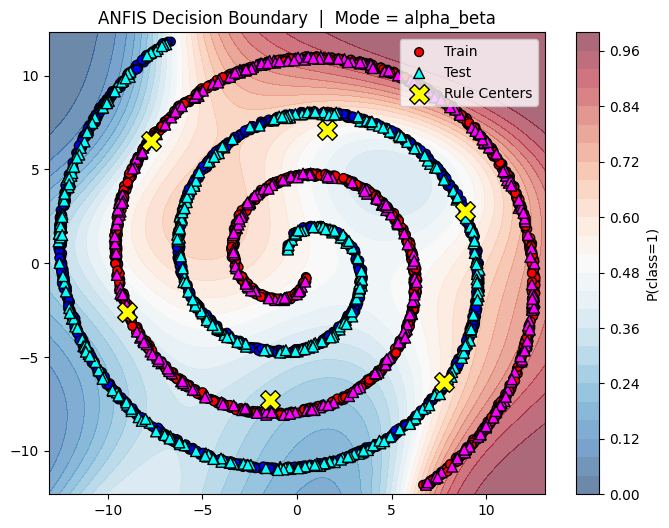

In [59]:
# ---------------------------
# 7: Plot decision boundary
# ---------------------------
plt.figure(figsize=(8, 6))

# Grid for visualization
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_tensor = torch.from_numpy(grid).to(device)

with torch.no_grad():
    prob_grid = torch.sigmoid(model(grid_tensor)).cpu().numpy().reshape(xx.shape)

# Decision boundary contour
contour = plt.contourf(xx, yy, prob_grid, levels=30, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="P(class=1)")

# Training data
plt.scatter(
    X_train[:, 0], X_train[:, 1], 
    c=y_train, cmap="bwr", edgecolor="k", s=40, label="Train"
)

# Test data
plt.scatter(
    X_test[:, 0], X_test[:, 1], 
    c=y_test, cmap="cool", edgecolor="k", s=60, marker="^", label="Test"
)

# Optional: show rule centers
plt.scatter(
    centers_init[:, 0], centers_init[:, 1],
    c="yellow", s=200, edgecolor="black", marker="X",
    label="Rule Centers"
)

plt.title(f"ANFIS Decision Boundary  |  Mode = {s_mode_choice}")
plt.legend()
plt.show()

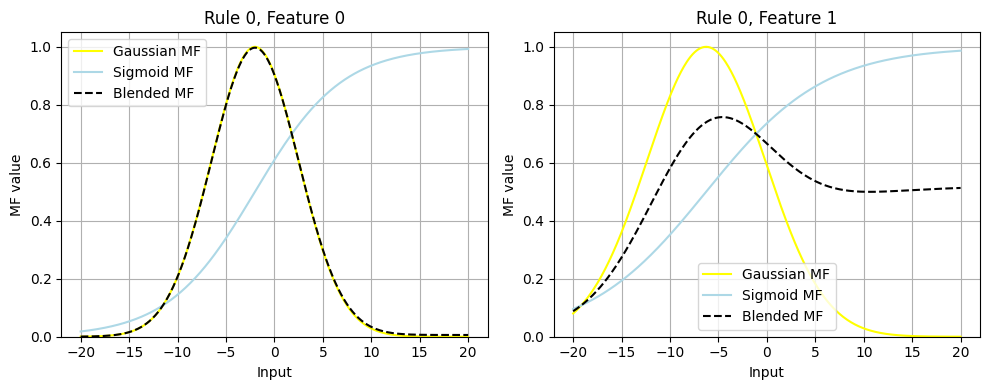

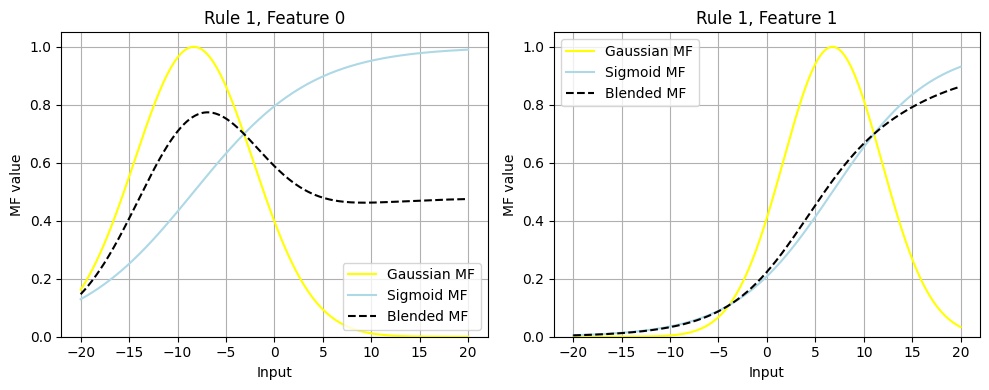

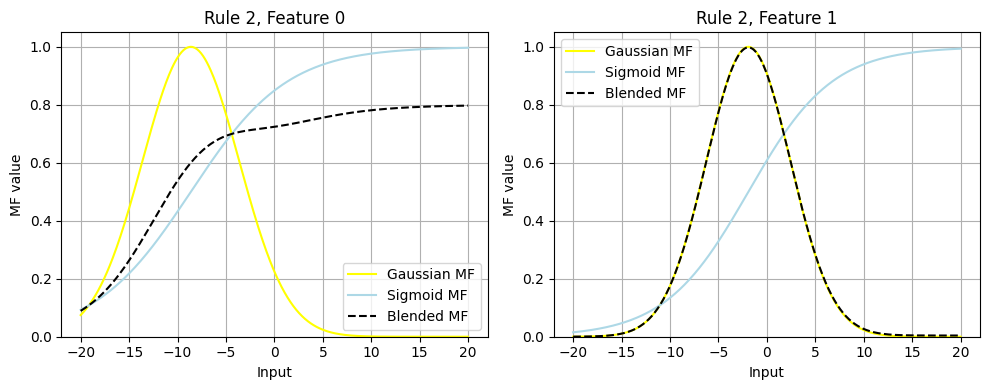

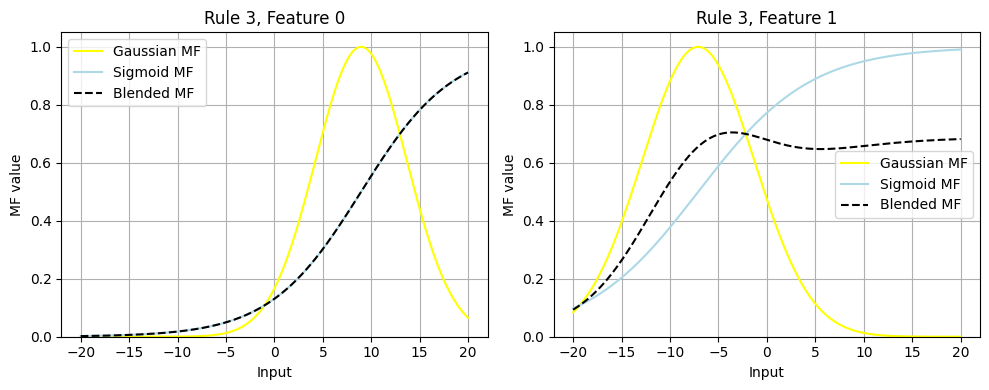

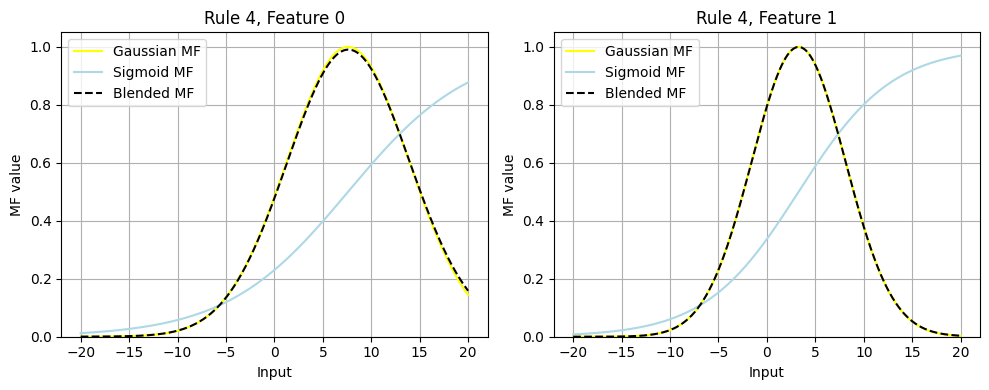

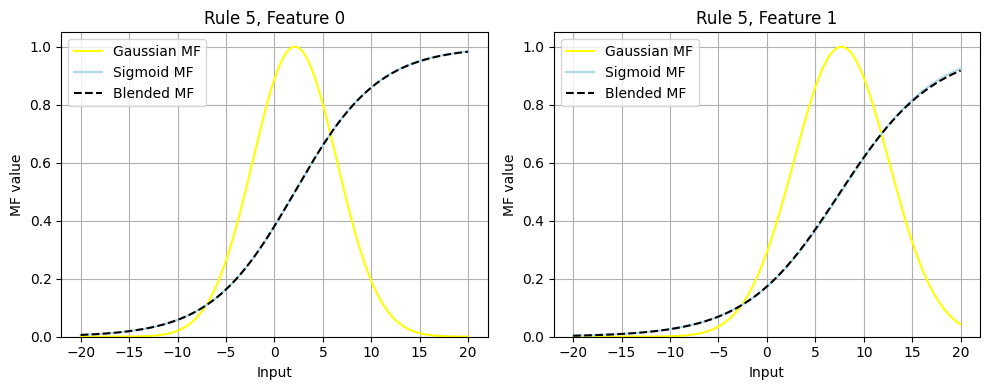

In [60]:
def plot_mfs_rule(model, rule, x_range=(-20, 20), n=400):
    """Plot Gaussian, Sigmoid, and blended MFs for all features of one rule in a single row."""
    
    n_features = model.n_inputs
    x = np.linspace(*x_range, n, dtype=np.float32)
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(next(model.parameters()).device)
    
    with torch.no_grad():
        w, mu_gauss, mu_sig, blend, mu_blend = model.mf_layer(x_tensor, return_parts=True)

    fig, axes = plt.subplots(1, n_features, figsize=(5*n_features, 4))
    if n_features == 1:
        axes = [axes]  # ensure axes is iterable
    
    for f, ax in enumerate(axes):
        mu_g = mu_gauss[:, rule, f].cpu().numpy()
        mu_s = mu_sig[:, rule, f].cpu().numpy()
        mu_b = mu_blend[:, rule, f].cpu().numpy()

        ax.plot(x, mu_g, label='Gaussian MF', color='yellow')
        ax.plot(x, mu_s, label='Sigmoid MF', color='lightblue')
        ax.plot(x, mu_b, '--', label='Blended MF', color='black')
        ax.set_title(f"Rule {rule}, Feature {f}")
        ax.set_xlabel("Input")
        ax.set_ylabel("MF value")
        ax.set_ylim(0, 1.05)
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

# Example usage: plot all features of each rule
for r in range(model.K):
    plot_mfs_rule(model, r)
